# Titanic - Data Preprocessing
## Exercises 1 to 7

We follow a consistent preprocessing pipeline:
1. Remove duplicates
2. Handle missing values
3. Feature engineering
4. Detect and treat outliers
5. Scale numerical features
6. Encode categorical variables
7. Transform the Age feature into groups

The dataset is loaded once here and reused throughout the notebook.

## Setup

In [5]:
!pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp314-cp314-win_amd64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl (37.3 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------------------------------------- 0/4 [threadpoolctl]
   ---------------------------------------- 0/4 [threadpoolctl]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- --

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Load the dataset once - we will build on the same DataFrame across all exercises
df = pd.read_csv("../titanic/train.csv")

print("Shape:", df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


---
## Exercise 1 - Duplicate Detection and Removal

We check for exact duplicate rows (identical on every column) and remove them.

In [7]:
rows_before = len(df)
print("Rows before:", rows_before)

# Count how many rows are exact duplicates
n_duplicates = df.duplicated().sum()
print("Duplicate rows found:", n_duplicates)

# Remove duplicates and reset the index so it stays clean
df = df.drop_duplicates().reset_index(drop=True)

rows_after = len(df)
print("Rows after:", rows_after)
print("Rows removed:", rows_before - rows_after)

Rows before: 891
Duplicate rows found: 0
Rows after: 891
Rows removed: 0


---
## Exercise 2 - Handling Missing Values

First we look at which columns have missing values and how many.

In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values per column:")
print(missing)
print()
print("As percentages:")
print(round(missing / len(df) * 100, 1))

Missing values per column:
Cabin       687
Age         177
Embarked      2
dtype: int64

As percentages:
Cabin       77.1
Age         19.9
Embarked     0.2
dtype: float64


We have three columns with missing data:

- **Age** (~20%): we impute with the median because Age is skewed and the median
  is more robust to outliers than the mean.
- **Embarked** (2 rows): we fill with the mode (most frequent port).
- **Cabin** (~77%): too many values missing to impute meaningfully.
  We drop the column entirely.

In [9]:
# --- Age: impute with median ---
# We use the median because the distribution of Age is right-skewed.
age_median = df["Age"].median()
df["Age"] = df["Age"].fillna(age_median)
print("Age - nulls remaining:", df["Age"].isnull().sum())

# --- Embarked: fill with mode ---
# Only 2 rows are missing; using the most frequent value is safe here.
embarked_mode = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(embarked_mode)
print("Embarked - nulls remaining:", df["Embarked"].isnull().sum())

# --- Cabin: drop the column ---
# Over 77% of values are missing. Imputing would be misleading,
# so we remove the column entirely.
df = df.drop(columns=["Cabin"])
print("Cabin column dropped.")

print()
print("Missing values after treatment:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("(No output above means no missing values remain.)")

Age - nulls remaining: 0
Embarked - nulls remaining: 0
Cabin column dropped.

Missing values after treatment:
Series([], dtype: int64)
(No output above means no missing values remain.)


---
## Exercise 3 - Feature Engineering

We create two new features before encoding:

1. **FamilySize** = SibSp + Parch + 1 (the +1 counts the passenger themselves)
2. **Title** extracted from the Name field (e.g. Mr, Mrs, Miss, ...)

In [10]:
# --- Family Size ---
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# --- Title ---
# Names look like: "Braund, Mr. Owen Harris"
# We extract the word that comes right after the comma and before the dot.
df["Title"] = df["Name"].str.extract(r",\s*([^.]+)\.")
print("Unique titles found:")
print(df["Title"].value_counts())

Unique titles found:
Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


In [11]:
# Rare titles are grouped into a single "Rare" category
# to avoid having many columns with very few observations after encoding.
common_titles = ["Mr", "Miss", "Mrs", "Master"]
df["Title"] = df["Title"].apply(lambda t: t if t in common_titles else "Rare")

print("Titles after grouping:")
print(df["Title"].value_counts())

Titles after grouping:
Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64


We do **not** scale numerical features yet - outlier treatment comes first.
We also hold off on encoding Sex, Embarked, and Title until Exercise 6,
so this cell just confirms the new features were created correctly.

In [12]:
print("New columns added: FamilySize, Title")
df[["Name", "SibSp", "Parch", "FamilySize", "Title"]].head(8)

New columns added: FamilySize, Title


,Name,SibSp,Parch,FamilySize,Title
0,"Braund, Mr. Owen Harris",1,0,2,Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,0,2,Mrs
2,"Heikkinen, Miss. Laina",0,0,1,Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,0,2,Mrs
4,"Allen, Mr. William Henry",0,0,1,Mr
5,"Moran, Mr. James",0,0,1,Mr
6,"McCarthy, Mr. Timothy J",0,0,1,Mr
7,"Palsson, Master. Gosta Leonard",3,1,5,Master


---
## Exercise 4 - Outlier Detection and Handling

We focus on **Fare** and **Age**, the two continuous numerical features
most likely to contain extreme values.

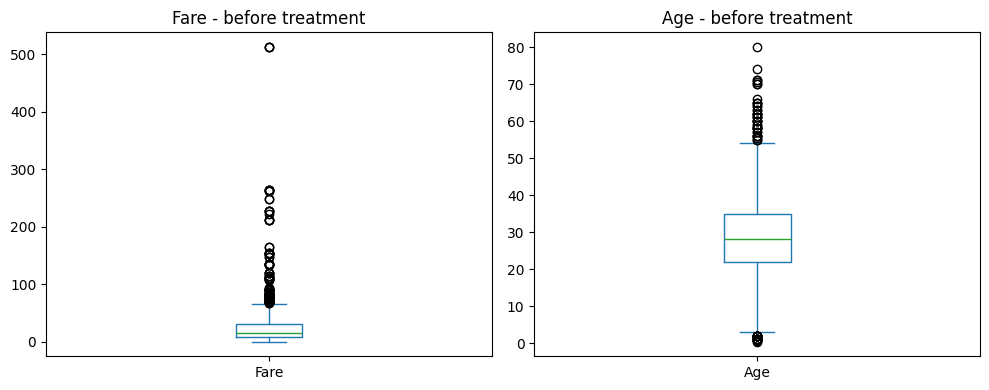

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df["Fare"].plot(kind="box", ax=axes[0], title="Fare - before treatment")
df["Age"].plot(kind="box", ax=axes[1], title="Age - before treatment")
plt.tight_layout()
plt.show()

**Fare** - we use quantile capping at 0.98 (top 2%).
We chose 0.98 rather than 0.99 because there are a handful of very extreme
fares (above 500) that would heavily distort scaling.

**Age** - the distribution is reasonable; no capping needed.
We apply a log transformation to Fare to reduce its right skew.

In [14]:
# --- IQR check on Fare ---
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)
IQR = Q3 - Q1
upper_iqr = Q3 + 1.5 * IQR
print(f"IQR upper fence for Fare: {upper_iqr:.2f}")
print(f"Values above fence: {(df['Fare'] > upper_iqr).sum()}")

print()
print("Fare quantiles:")
print(df["Fare"].quantile([0.95, 0.97, 0.98, 0.99, 1.0]))

IQR upper fence for Fare: 65.63
Values above fence: 116

Fare quantiles:
0.95    112.07915
0.97    151.55000
0.98    211.33750
0.99    249.00622
1.00    512.32920
Name: Fare, dtype: float64


In [15]:
# Quantile capping at 0.98 for Fare
# Values above this threshold are clipped to the 98th percentile value.
cap_98 = df["Fare"].quantile(0.98)
print(f"Capping Fare at: {cap_98:.2f}")
df["Fare"] = df["Fare"].clip(upper=cap_98)

# Log transformation - we add 1 first to handle zero fares (log(0) is undefined)
df["Fare_log"] = np.log1p(df["Fare"])

print("Fare after capping - max:", df["Fare"].max())

Capping Fare at: 211.34
Fare after capping - max: 211.3375


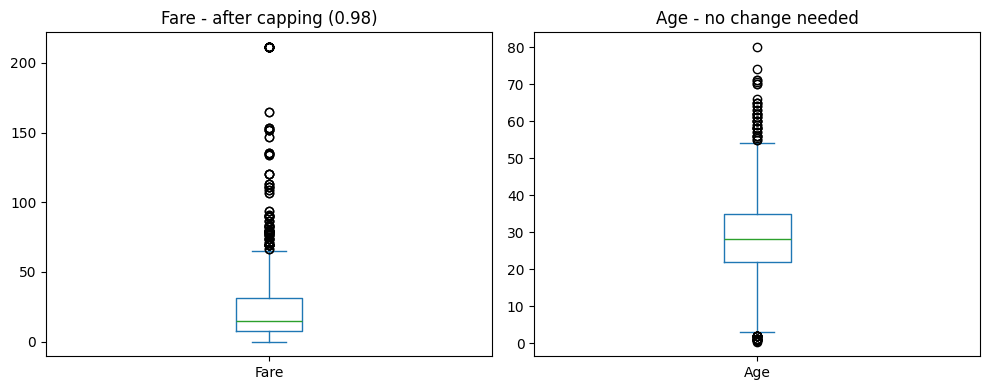

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df["Fare"].plot(kind="box", ax=axes[0], title="Fare - after capping (0.98)")
df["Age"].plot(kind="box", ax=axes[1], title="Age - no change needed")
plt.tight_layout()
plt.show()

---
## Exercise 5 - Data Standardization and Normalization

We scale numerical features **after** outlier treatment to avoid distortion.

- **StandardScaler** (mean=0, std=1) for Age, which is roughly bell-shaped.
- **MinMaxScaler** (range [0,1]) for Fare_log, which is still somewhat skewed.

In [17]:
standard_cols = ["Age"]
minmax_cols   = ["Fare_log"]

# StandardScaler
scaler_std = StandardScaler()
df[standard_cols] = scaler_std.fit_transform(df[standard_cols])

# MinMaxScaler
scaler_mm = MinMaxScaler()
df[minmax_cols] = scaler_mm.fit_transform(df[minmax_cols])

print("Age after StandardScaler - mean:", round(df["Age"].mean(), 4), "std:", round(df["Age"].std(), 4))
print("Fare_log after MinMaxScaler - min:", round(df["Fare_log"].min(), 4), "max:", round(df["Fare_log"].max(), 4))

Age after StandardScaler - mean: 0.0 std: 1.0006
Fare_log after MinMaxScaler - min: 0.0 max: 1.0


---
## Exercise 6 - Feature Encoding

We now encode the remaining categorical columns:

- **Sex** and **Embarked** are nominal -> one-hot encoding (no ordinal relationship).
- **Title** is also nominal -> one-hot encoding.

We use `drop_first=True` for Sex (only 2 categories) to avoid multicollinearity.
For Embarked and Title we keep all dummies for clarity.

In [18]:
print("Remaining categorical columns:")
print(df.select_dtypes(include="object").columns.tolist())

Remaining categorical columns:
['Name', 'Sex', 'Ticket', 'Embarked', 'Title']


C:\Users\yadji\AppData\Local\Temp\ipykernel_16864\2495158341.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.select_dtypes(include="object").columns.tolist())


In [19]:
# One-hot encode Sex (drop_first removes one redundant column)
sex_dummies = pd.get_dummies(df["Sex"], prefix="Sex", drop_first=True)

# One-hot encode Embarked (3 ports: C, Q, S)
embarked_dummies = pd.get_dummies(df["Embarked"], prefix="Embarked")

# One-hot encode Title
title_dummies = pd.get_dummies(df["Title"], prefix="Title")

# Merge all encoded columns into the main DataFrame
df = pd.concat([df, sex_dummies, embarked_dummies, title_dummies], axis=1)

# Drop the original text columns - they are now represented by the dummies
df = df.drop(columns=["Sex", "Embarked", "Title", "Name", "Ticket"])

print("Shape after encoding:", df.shape)
df.head()

Shape after encoding: (891, 18)


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,Fare_log,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0,3,-0.565736,1,0,7.2500,2,0.393830,True,False,False,True,False,False,True,False,False
1,2,1,1,0.663861,1,0,71.2833,2,0.798890,False,True,False,False,False,False,False,True,False
2,3,1,3,-0.258337,0,0,7.9250,1,0.408508,False,False,False,True,False,True,False,False,False
3,4,1,1,0.433312,1,0,53.1000,2,0.744812,False,False,False,True,False,False,False,True,False
4,5,0,3,0.433312,0,0,8.0500,1,0.411103,True,False,False,True,False,False,True,False,False


---
## Exercise 7 - Data Transformation for Age Feature

We originally scaled Age in Exercise 5. Here we work with the **original Age values**
to create meaningful life-stage bins. We re-read the pre-scaled value from
the raw median-imputed column we saved before scaling, or we compute it
from the scaled column by inverse-transforming.

For simplicity we recreate the bins from the original dataset loaded fresh,
then one-hot encode them.

In [20]:
# Reload the original age values (before scaling) via inverse transform
# so we can apply pd.cut() on real age values, not z-scores.
age_original = scaler_std.inverse_transform(df[["Age"]])
age_series = pd.Series(age_original.flatten(), name="Age_raw")

# Define life-stage bins
bins   = [0, 12, 18, 60, 100]
labels = ["child", "teen", "adult", "senior"]

df["AgeGroup"] = pd.cut(age_series, bins=bins, labels=labels)

print("Age group distribution:")
print(df["AgeGroup"].value_counts().sort_index())

Age group distribution:
AgeGroup
child      69
teen       70
adult     730
senior     22
Name: count, dtype: int64


In [21]:
# One-hot encode the age groups
age_dummies = pd.get_dummies(df["AgeGroup"], prefix="AgeGroup")
df = pd.concat([df, age_dummies], axis=1)
df = df.drop(columns=["AgeGroup"])

print("Shape after adding age group dummies:", df.shape)
print("New columns:", [c for c in df.columns if c.startswith("AgeGroup")])
df.head()

Shape after adding age group dummies: (891, 22)
New columns: ['AgeGroup_child', 'AgeGroup_teen', 'AgeGroup_adult', 'AgeGroup_senior']


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,Fare_log,Sex_male,...,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,AgeGroup_child,AgeGroup_teen,AgeGroup_adult,AgeGroup_senior
0,1,0,3,-0.565736,1,0,7.2500,2,0.393830,True,...,True,False,False,True,False,False,False,False,True,False
1,2,1,1,0.663861,1,0,71.2833,2,0.798890,False,...,False,False,False,False,True,False,False,False,True,False
2,3,1,3,-0.258337,0,0,7.9250,1,0.408508,False,...,True,False,True,False,False,False,False,False,True,False
3,4,1,1,0.433312,1,0,53.1000,2,0.744812,False,...,True,False,False,False,True,False,False,False,True,False
4,5,0,3,0.433312,0,0,8.0500,1,0.411103,True,...,True,False,False,True,False,False,False,False,True,False


---
## Final Dataset Overview

We summarize all transformations applied throughout the pipeline.

In [22]:
print("Final shape:", df.shape)
print()
print("Columns:")
for col in df.columns:
    print(f"  {col:30s}  dtype={df[col].dtype}")
print()
print("Remaining nulls:", df.isnull().sum().sum())

Final shape: (891, 22)

Columns:
  PassengerId                     dtype=int64
  Survived                        dtype=int64
  Pclass                          dtype=int64
  Age                             dtype=float64
  SibSp                           dtype=int64
  Parch                           dtype=int64
  Fare                            dtype=float64
  FamilySize                      dtype=int64
  Fare_log                        dtype=float64
  Sex_male                        dtype=bool
  Embarked_C                      dtype=bool
  Embarked_Q                      dtype=bool
  Embarked_S                      dtype=bool
  Title_Master                    dtype=bool
  Title_Miss                      dtype=bool
  Title_Mr                        dtype=bool
  Title_Mrs                       dtype=bool
  Title_Rare                      dtype=bool
  AgeGroup_child                  dtype=bool
  AgeGroup_teen                   dtype=bool
  AgeGroup_adult                  dtype=bool
  AgeGr